# EDA Step 4: 이상치 탐지 (Outlier Detection)

**목표**: 수치형 변수의 이상치를 식별하고 처리 전략을 결정합니다.

**분석 항목**:
- IQR 방법 (Q1-1.5*IQR, Q3+1.5*IQR)
- Z-score 방법 (|Z| > 3)
- 이상치 상세 프로파일 (fare=512, fare=0, sibsp=8)
- 이상치 vs 생존율 비교
- 처리 전략 결정

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

df = sns.load_dataset('titanic')
print(f'Data loaded: {df.shape}')

Data loaded: (891, 15)


## 4.1 IQR 방법

In [2]:
numeric_vars = ['age', 'fare', 'sibsp', 'parch']

iqr_results = []
for var in numeric_vars:
    data = df[var].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data < lower) | (data > upper)]
    iqr_results.append({
        'Variable': var, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower Fence': lower, 'Upper Fence': upper,
        'Outlier Count': len(outliers),
        'Outlier %': len(outliers) / len(data) * 100
    })

iqr_df = pd.DataFrame(iqr_results)
print('IQR Outlier Detection')
print('=' * 80)
print(iqr_df.to_string(index=False, float_format='{:.2f}'.format))

IQR Outlier Detection
Variable    Q1    Q3   IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
     age 20.12 38.00 17.88        -6.69        64.81             11       1.54
    fare  7.91 31.00 23.09       -26.72        65.63            116      13.02
   sibsp  0.00  1.00  1.00        -1.50         2.50             46       5.16
   parch  0.00  0.00  0.00         0.00         0.00            213      23.91


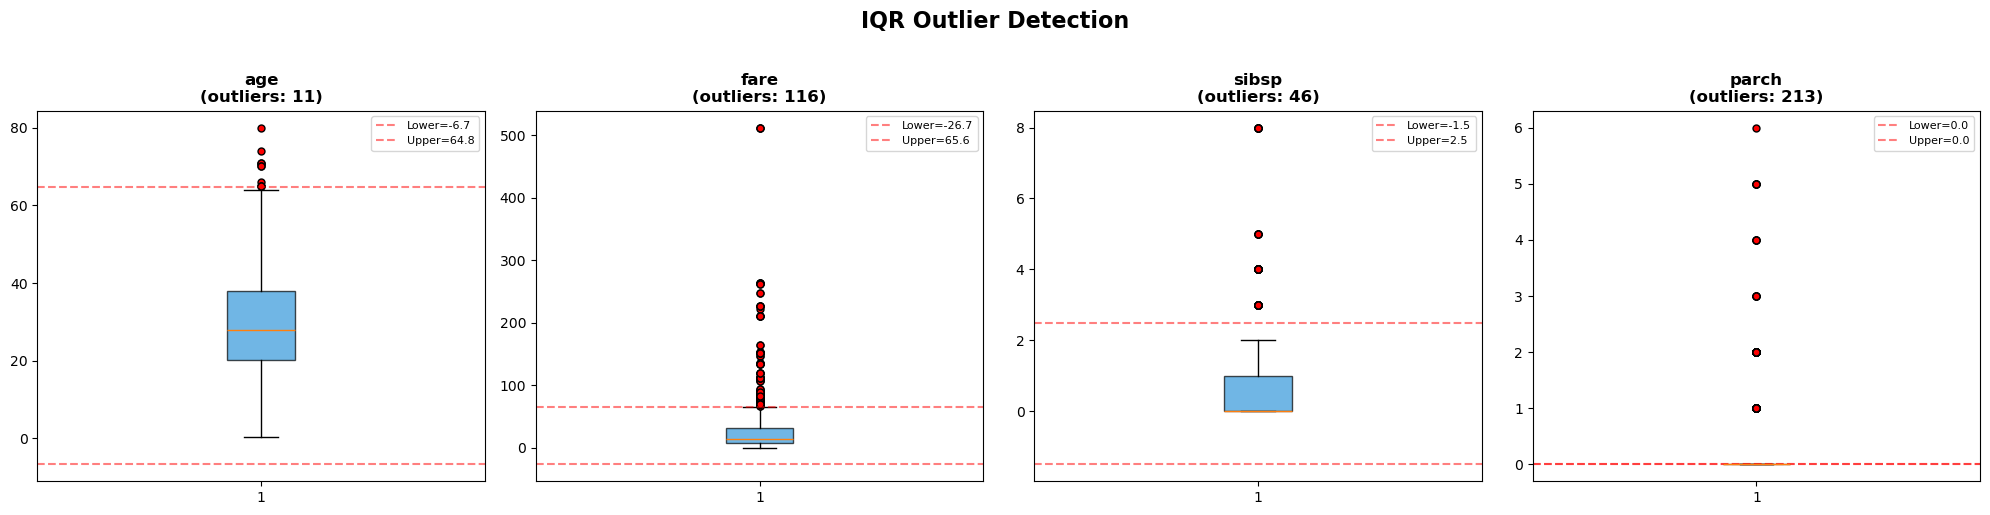

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, var in enumerate(numeric_vars):
    ax = axes[idx]
    data = df[var].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    
    outlier_count = len(data[(data < lower) | (data > upper)])
    ax.set_title(f'{var}\n(outliers: {outlier_count})', fontsize=12, fontweight='bold')
    ax.axhline(y=lower, color='red', linestyle='--', alpha=0.5, label=f'Lower={lower:.1f}')
    ax.axhline(y=upper, color='red', linestyle='--', alpha=0.5, label=f'Upper={upper:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('IQR Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step4_iqr_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 Z-score 방법

In [4]:
zscore_results = []
for var in numeric_vars:
    data = df[var].dropna()
    z = np.abs(stats.zscore(data))
    outliers_z3 = (z > 3).sum()
    outliers_z2 = (z > 2).sum()
    zscore_results.append({
        'Variable': var,
        '|Z|>2 Count': outliers_z2,
        '|Z|>2 %': outliers_z2 / len(data) * 100,
        '|Z|>3 Count': outliers_z3,
        '|Z|>3 %': outliers_z3 / len(data) * 100,
    })

zscore_df = pd.DataFrame(zscore_results)
print('Z-score Outlier Detection')
print('=' * 60)
print(zscore_df.to_string(index=False, float_format='{:.2f}'.format))

Z-score Outlier Detection
Variable  |Z|>2 Count  |Z|>2 %  |Z|>3 Count  |Z|>3 %
     age           29     4.06            2     0.28
    fare           38     4.26           20     2.24
   sibsp           46     5.16           30     3.37
   parch           95    10.66           15     1.68


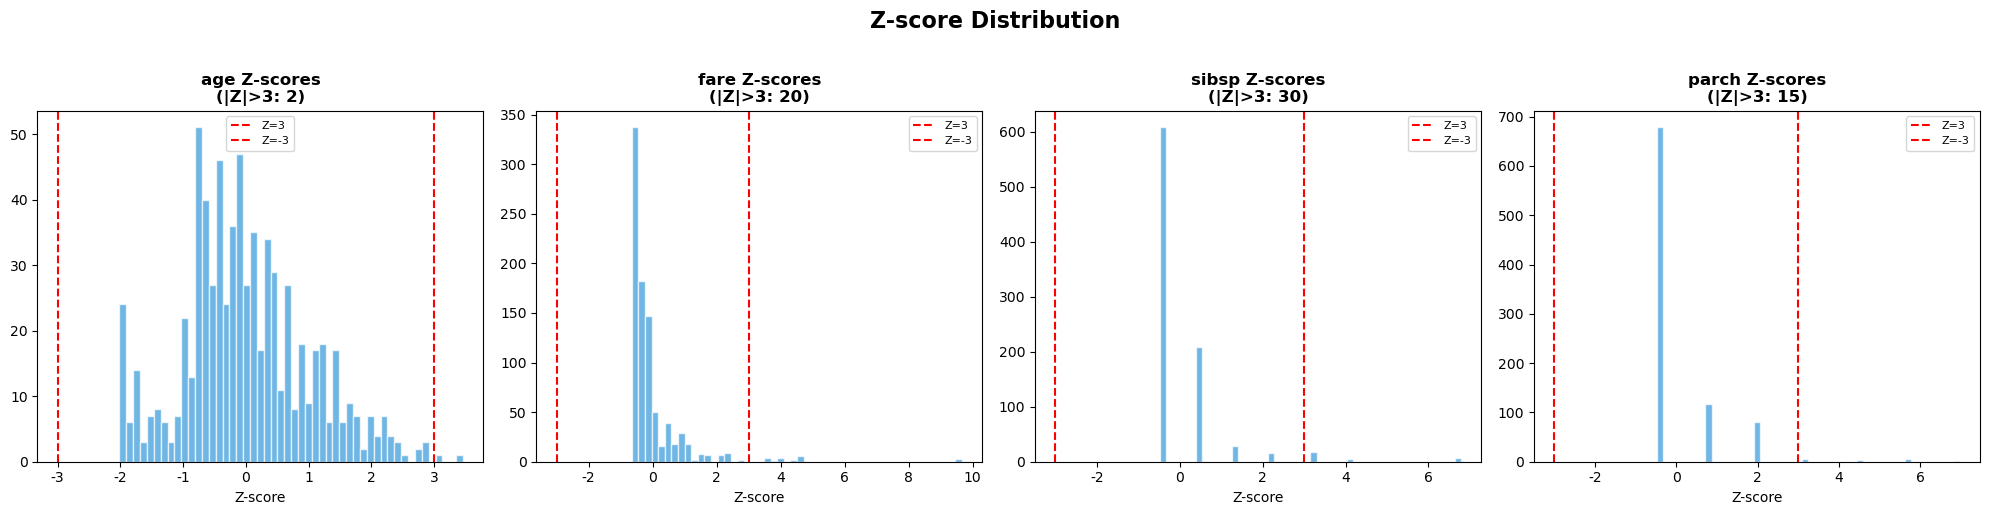

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, var in enumerate(numeric_vars):
    ax = axes[idx]
    data = df[var].dropna()
    z = stats.zscore(data)
    ax.hist(z, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
    ax.axvline(x=3, color='red', linestyle='--', label='Z=3')
    ax.axvline(x=-3, color='red', linestyle='--', label='Z=-3')
    outlier_count = (np.abs(z) > 3).sum()
    ax.set_title(f'{var} Z-scores\n(|Z|>3: {outlier_count})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Z-score')
    ax.legend(fontsize=8)

plt.suptitle('Z-score Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step4_zscore_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 이상치 상세 프로파일

In [6]:
# fare 최고값 승객
print('=== Top 10 Fare Passengers ===')
top_fare = df.nlargest(10, 'fare')[['pclass', 'sex', 'age', 'fare', 'embarked', 'survived', 'who']]
print(top_fare.to_string())

print(f'\n=== fare=0 Passengers ({(df["fare"]==0).sum()} rows) ===')
zero_fare = df[df['fare'] == 0][['pclass', 'sex', 'age', 'embarked', 'survived', 'who']]
print(zero_fare.to_string())
print(f'Survival rate (fare=0): {df[df["fare"]==0]["survived"].mean():.3f}')
print(f'Pclass: {df[df["fare"]==0]["pclass"].value_counts().to_dict()}')

print(f'\n=== sibsp Max Passengers ===')
high_sibsp = df[df['sibsp'] >= 4][['pclass', 'sex', 'age', 'sibsp', 'parch', 'survived']]
print(high_sibsp.to_string())

print(f'\n=== parch Max Passengers ===')
high_parch = df[df['parch'] >= 4][['pclass', 'sex', 'age', 'sibsp', 'parch', 'survived']]
print(high_parch.to_string())

=== Top 10 Fare Passengers ===
     pclass     sex   age      fare embarked  survived    who
258       1  female  35.0  512.3292        C         1  woman
679       1    male  36.0  512.3292        C         1    man
737       1    male  35.0  512.3292        C         1    man
27        1    male  19.0  263.0000        S         0    man
88        1  female  23.0  263.0000        S         1  woman
341       1  female  24.0  263.0000        S         1  woman
438       1    male  64.0  263.0000        S         0    man
311       1  female  18.0  262.3750        C         1  woman
742       1  female  21.0  262.3750        C         1  woman
118       1    male  24.0  247.5208        C         0    man

=== fare=0 Passengers (15 rows) ===
     pclass   sex   age embarked  survived  who
179       3  male  36.0        S         0  man
263       1  male  40.0        S         0  man
271       3  male  25.0        S         1  man
277       2  male   NaN        S         0  man
302       

## 4.4 이상치 vs 생존율

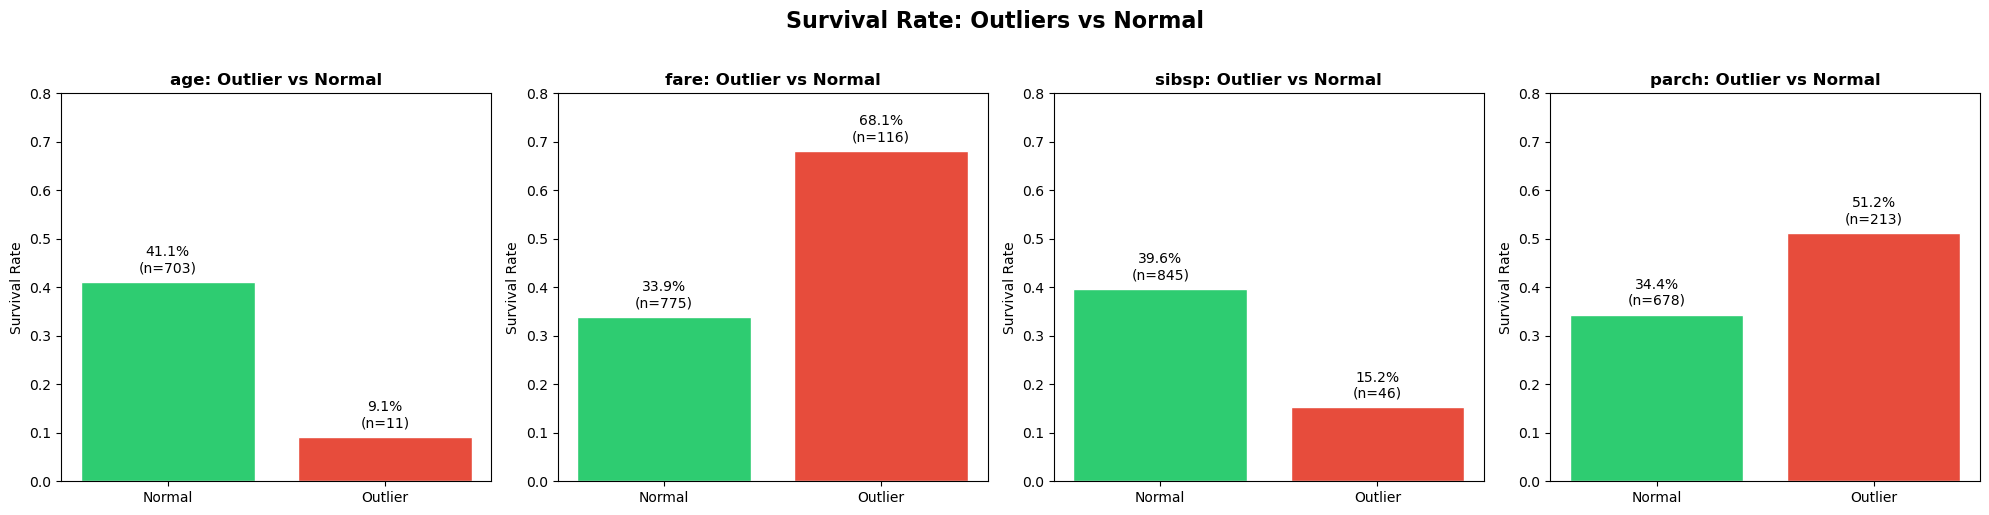

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, var in enumerate(numeric_vars):
    ax = axes[idx]
    data = df[[var, 'survived']].dropna()
    q1, q3 = data[var].quantile(0.25), data[var].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    data['is_outlier'] = ((data[var] < lower) | (data[var] > upper)).astype(int)
    
    surv_normal = data[data['is_outlier'] == 0]['survived'].mean()
    surv_outlier = data[data['is_outlier'] == 1]['survived'].mean()
    count_normal = (data['is_outlier'] == 0).sum()
    count_outlier = (data['is_outlier'] == 1).sum()
    
    bars = ax.bar(['Normal', 'Outlier'], [surv_normal, surv_outlier],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white')
    for bar, rate, n in zip(bars, [surv_normal, surv_outlier], [count_normal, count_outlier]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}\n(n={n})', ha='center', fontsize=10)
    ax.set_title(f'{var}: Outlier vs Normal', fontsize=12, fontweight='bold')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 0.8)

plt.suptitle('Survival Rate: Outliers vs Normal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step4_outlier_vs_survival.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 처리 전략 결정

In [8]:
strategy = pd.DataFrame({
    'Variable': ['age', 'fare', 'sibsp', 'parch'],
    'Outlier Count (IQR)': [iqr_df.loc[iqr_df['Variable']==v, 'Outlier Count'].values[0] for v in ['age', 'fare', 'sibsp', 'parch']],
    'Strategy': ['Keep as-is', 'Log Transform', 'Keep as-is', 'Keep as-is'],
    'Rationale': [
        'Max=80 is reasonable. No extreme values.',
        'Extreme skew (4.79). Log reduces skew. High-fare passengers have high survival (informative).',
        'Rare but informative (family size signal). Only 18 values >= 4.',
        'Rare but informative (family size signal). Only 6 values >= 4.'
    ]
})

print('=' * 80)
print('OUTLIER HANDLING STRATEGY')
print('=' * 80)
for _, row in strategy.iterrows():
    print(f'\n--- {row["Variable"]} ---')
    print(f'  Outliers (IQR): {row["Outlier Count (IQR)"]}')
    print(f'  Strategy: {row["Strategy"]}')
    print(f'  Rationale: {row["Rationale"]}')

print('\n\n=== IMPORTANT ===')
print('Do NOT remove fare outliers - high-fare passengers are 1st class with HIGH survival rate.')
print('Removing them would lose critical positive class information and hurt Recall.')

OUTLIER HANDLING STRATEGY

--- age ---
  Outliers (IQR): 11
  Strategy: Keep as-is
  Rationale: Max=80 is reasonable. No extreme values.

--- fare ---
  Outliers (IQR): 116
  Strategy: Log Transform
  Rationale: Extreme skew (4.79). Log reduces skew. High-fare passengers have high survival (informative).

--- sibsp ---
  Outliers (IQR): 46
  Strategy: Keep as-is
  Rationale: Rare but informative (family size signal). Only 18 values >= 4.

--- parch ---
  Outliers (IQR): 213
  Strategy: Keep as-is
  Rationale: Rare but informative (family size signal). Only 6 values >= 4.


=== IMPORTANT ===
Do NOT remove fare outliers - high-fare passengers are 1st class with HIGH survival rate.
Removing them would lose critical positive class information and hurt Recall.


In [9]:
# Safety Check
assert SEED == 42, 'SEED must be 42!'
print('Safety Check Passed!')

Safety Check Passed!


---
## Summary

### 핵심 발견사항

1. **fare**: IQR 이상치 116건 (13.0%) - 가장 많지만, 1등급 고생존율 승객이므로 제거하면 안됨
2. **fare=0**: 15건, 대부분 3등급 남성 (생존율 매우 낮음) - 특수 케이스로 유지
3. **sibsp/parch**: 극단값 매우 적지만 가족 크기 신호로 유용
4. **age**: IQR 기준 이상치 1건뿐 (max=80), 실질적 이상치 없음

### 처리 전략

| 변수 | 전략 | 근거 |
|------|------|------|
| age | 유지 | 극단값 없음 |
| fare | Log 변환 | 왜도 감소, 정보 보존 |
| sibsp | 유지 | 가족 크기 신호 |
| parch | 유지 | 가족 크기 신호 |

### 다음 단계
→ **EDA Step 5: 다변량 분석** 으로 진행